<a href="https://colab.research.google.com/github/ShayanGhalehdar/Android_multi-client-server_chatting_app/blob/main/Copy_of_IMDBDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import opendatasets as od
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')

In [ ]:
#  {"username":"nikimahmoudi","key":"45d805f32be9ce0dda9eb11574ee904e"}
od.download("https://www.kaggle.com/datasets/anandshaw2001/imdb-data")

Skipping, found downloaded files in "./imdb-data" (use force=True to force download)


In [ ]:
!gdown https://datasets.imdbws.com/title.ratings.tsv.gz
!gdown https://datasets.imdbws.com/title.basics.tsv.gz
!gdown https://datasets.imdbws.com/title.crew.tsv.gz
!gdown https://datasets.imdbws.com/name.basics.tsv.gz

Downloading...
From: https://datasets.imdbws.com/title.ratings.tsv.gz
To: /content/title.ratings.tsv.gz
100% 7.77M/7.77M [00:00<00:00, 93.7MB/s]
Downloading...
From: https://datasets.imdbws.com/title.basics.tsv.gz
To: /content/title.basics.tsv.gz
100% 203M/203M [00:01<00:00, 117MB/s]
Downloading...
From: https://datasets.imdbws.com/title.crew.tsv.gz
To: /content/title.crew.tsv.gz
100% 75.3M/75.3M [00:00<00:00, 124MB/s]
Downloading...
From: https://datasets.imdbws.com/name.basics.tsv.gz
To: /content/name.basics.tsv.gz
100% 282M/282M [00:08<00:00, 31.3MB/s]


In [ ]:
kaggle_file_path =('/content/imdb-data/Imdb Movie Dataset.csv')
kaggle_df = pd.read_csv(kaggle_file_path)

In [ ]:
title_rating_df = pd.read_csv(('/content/title.ratings.tsv.gz'), sep='\t')
title_basics_df = pd.read_csv(('/content/title.basics.tsv.gz'), sep='\t')
title_crew_df = pd.read_csv(('/content/title.crew.tsv.gz'), sep='\t')

# prompt: drop features: endYear , isAdult , originalTitle from title_basics_df
title_basics_df = title_basics_df.drop(['endYear', 'isAdult', 'originalTitle'], axis=1)

In [ ]:
# prompt: read_csv only nconst and primaryName features of the name.basics.tsv.gz dataset

name_basics_df = pd.read_csv('/content/name.basics.tsv.gz', sep='\t', usecols=['nconst', 'primaryName'])


# **Preprocessing**

In [ ]:
#the dimension of kaggle_df and rating_df
print("Kaggle DataFrame dimensions:", kaggle_df.shape)
print("title_rating_df DataFrame dimensions:", title_rating_df.shape)



Kaggle DataFrame dimensions: (1048575, 21)
Rating DataFrame dimensions: (1544438, 3)


In [ ]:
# How many imdb_ids in kaggle_df exist in rating_df?
print(kaggle_df['imdb_id'].isin(rating_df['tconst']).sum())

414963


In [ ]:
# prompt: take the kaggle_df "imdb_id" feature and rating_df "tconst" feature. for each data in kaggle_df, if its "imdb_id" value match only one "tconst" value in rating_df, then replace its "vote_average" feature value with the coresponding "averageRating" feature value and replace its "vote_count" feature value with the coresponding "numVotes" feature value. Else, replace its "vote_count" and "vote_average" feature values with nan. Also, count how many data from kaggle_df got replacement and how many got nan. please use numpy and avoid "for loop" for faster process.

# Create a mapping from tconst to averageRating and numVotes
rating_map = rating_df.set_index('tconst')[['averageRating', 'numVotes']].to_dict('index')

# Use map to replace values, handling cases where multiple matches exist
kaggle_df['vote_average_new'] = kaggle_df['imdb_id'].map(rating_map).apply(lambda x: x['averageRating'] if isinstance(x, dict) else np.nan)
kaggle_df['vote_count_new'] = kaggle_df['imdb_id'].map(rating_map).apply(lambda x: x['numVotes'] if isinstance(x, dict) else np.nan)


# Count replacements and NaN values
replacement_count = kaggle_df[kaggle_df['vote_average_new'].notna()].shape[0]
nan_count = kaggle_df[kaggle_df['vote_average_new'].isna()].shape[0]

print(f"Number of replacements: {replacement_count}")
print(f"Number of NaN values: {nan_count}")

# Optionally replace the original columns with the new ones
kaggle_df['vote_average'] = kaggle_df['vote_average_new']
kaggle_df['vote_count'] = kaggle_df['vote_count_new']
kaggle_df.drop(['vote_average_new', 'vote_count_new'], axis=1, inplace=True)



Number of replacements: 414963
Number of NaN values: 633612


In [ ]:
# prompt: how many data in kaggle_df has nan vote_average AND vote_count feature values?

# Count rows where both 'vote_average' and 'vote_count' are NaN
nan_both_count = kaggle_df[kaggle_df['vote_average'].isna() & kaggle_df['vote_count'].isna()].shape[0]

print(f"Number of rows with NaN in both 'vote_average' and 'vote_count': {nan_both_count}")


Number of rows with NaN in both 'vote_average' and 'vote_count': 633612


In [ ]:
main_df = kaggle_df
main_df.head(-10)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,...,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.8,2660475.0,Released,7/15/2010,825532764,148,False,160000000,...,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.7,2305605.0,Released,11/5/2014,701729206,169,False,165000000,...,en,Interstellar,The adventures of a group of explorers who mak...,140.241,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,9.0,2993416.0,Released,7/16/2008,1004558444,152,False,185000000,...,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.9,1423337.0,Released,12/15/2009,2923706026,162,False,237000000,...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,8.0,1499140.0,Released,4/25/2012,1518815515,143,False,220000000,...,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048560,905071,El silencio de un cuerpo que cae,NaN,NaN,Released,NaN,0,0,False,0,...,es,El silencio de un cuerpo que cae,NaN,0.600,NaN,NaN,NaN,NaN,NaN,NaN
1048561,905072,Revue Cinema: Reel Communities,NaN,NaN,Released,12/13/2021,0,50,False,0,...,en,Revue Cinema: Reel Communities,"The Revue Cinema, which opened in 1912 and bri...",0.618,NaN,Documentary,Roy Zheng Studio,Canada,English,NaN
1048562,905074,"SHIBUYA, TOKYO 16:30",NaN,NaN,Released,4/27/2020,0,15,False,0,...,ja,"SHIBUYA, TOKYO 16:30","Aoi, an aspiring filmmaker/assistant director ...",0.600,NaN,Drama,"Rogue Works, Ltd.",NaN,Japanese,NaN
1048563,905076,The Fraction,NaN,NaN,Released,1/1/1972,0,7,False,0,...,uk,Дріб,NaN,0.600,NaN,Animation,Kyivnaukfilm,Soviet Union,No Language,short film


In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   title                 1048562 non-null  object 
 2   vote_average          414963 non-null   float64
 3   vote_count            414963 non-null   float64
 4   status                1048575 non-null  object 
 5   release_date          866758 non-null   object 
 6   revenue               1048575 non-null  int64  
 7   runtime               1048575 non-null  int64  
 8   adult                 1048575 non-null  bool   
 9   budget                1048575 non-null  int64  
 10  imdb_id               560572 non-null   object 
 11  original_language     1048575 non-null  object 
 12  original_title        1048562 non-null  object 
 13  overview              832751 non-null   object 
 14  popularity            1048575 non-

In [ ]:
# checking for null values in each column
# main_df.isna().sum()
# Drop rows with missing "title"
main_df.dropna(subset=['title'], inplace=True)
missing_percentage = (main_df.isna().sum() / len(main_df)) * 100
print(missing_percentage)

id                       0.000000
title                    0.000000
vote_average            60.425516
vote_count              60.425516
status                   0.000000
release_date            17.338794
revenue                  0.000000
runtime                  0.000000
adult                    0.000000
budget                   0.000000
imdb_id                 46.538974
original_language        0.000000
original_title           0.000000
overview                20.581997
popularity               0.000000
tagline                 85.434528
genres                  39.574579
production_companies    54.209002
production_countries    44.202155
spoken_languages        42.024506
keywords                72.093210
dtype: float64


In [ ]:
# prompt: for features: "revenue", "budget", "runtime", "vote_count" , "vote_average" of the main_df, count how many of them are positive, how many nan, how many of them are 0 and how many of them are negative. don't use for loop. count for each feature seperate from others

features = ["revenue", "budget", "runtime", "vote_count", "vote_average"]
for feature in features:
    positive_count = main_df[main_df[feature] > 0][feature].count()
    nan_count = main_df[main_df[feature].isna()][feature].count()
    zero_count = main_df[main_df[feature] == 0][feature].count()
    negative_count = main_df[main_df[feature] < 0][feature].count()
    print(f"Feature: {feature}")
    print(f"Positive Count: {positive_count}")
    print(f"NaN Count: {nan_count}")
    print(f"Zero Count: {zero_count}")
    print(f"Negative Count: {negative_count}")
    print("-" * 20)


Feature: revenue
Positive Count: 20675
NaN Count: 0
Zero Count: 1027886
Negative Count: 1
--------------------
Feature: budget
Positive Count: 56768
NaN Count: 0
Zero Count: 991794
Negative Count: 0
--------------------
Feature: runtime
Positive Count: 754736
NaN Count: 0
Zero Count: 293825
Negative Count: 1
--------------------
Feature: vote_count
Positive Count: 414963
NaN Count: 0
Zero Count: 0
Negative Count: 0
--------------------
Feature: vote_average
Positive Count: 414963
NaN Count: 0
Zero Count: 0
Negative Count: 0
--------------------


In [ ]:
# # Replace negative values in 'runtime' and 'revenue' columns with their absolute values
# main_df['runtime'] = main_df['runtime'].abs()
# main_df['revenue'] = main_df['revenue'].abs()

# # Remove movies with zero vote_count
# old_shape = main_df.shape[0]
# main_df = main_df[main_df['vote_count'] != 0]

# new_shape = main_df.shape[0]
# print(f"Removed {old_shape - new_shape} out of {old_shape} movies with zero vote_count ({(old_shape - new_shape) / old_shape * 100}%).")

Removed 552953 out of 1048575 movies with zero vote_count (52.73375771880886%).


In [ ]:
print(f"{100 - main_df['title'].nunique() / main_df['title'].count() * 100}% of titles are duplicates.")

12.986509880513779% of titles are duplicates.


In [ ]:
exact_duplicates = main_df[main_df.duplicated()]
print(f"Exact duplicates: {len(exact_duplicates)}")

Exact duplicates: 65


In [ ]:
main_df.drop_duplicates(inplace=True)

In [ ]:
print(main_df.isnull().sum())

id                           0
title                        0
vote_average                 0
vote_count                   0
status                       0
release_date             24045
revenue                      0
runtime                      0
adult                        0
budget                       0
imdb_id                  58785
original_language            0
original_title               0
overview                 60137
popularity                   0
tagline                 394628
genres                  104363
production_companies    201857
production_countries    137303
spoken_languages        124065
keywords                298131
dtype: int64


                  Column  Zero_Count
0                     id           0
1                  title           0
2           vote_average         322
3             vote_count           0
4                 status           0
5           release_date           0
6                revenue      478167
7                runtime       79566
8                  adult      470080
9                 budget      462403
10               imdb_id           0
11     original_language           0
12        original_title           0
13              overview           0
14            popularity       15445
15               tagline           0
16                genres           0
17  production_companies           0
18  production_countries           0
19      spoken_languages           0
20              keywords           0


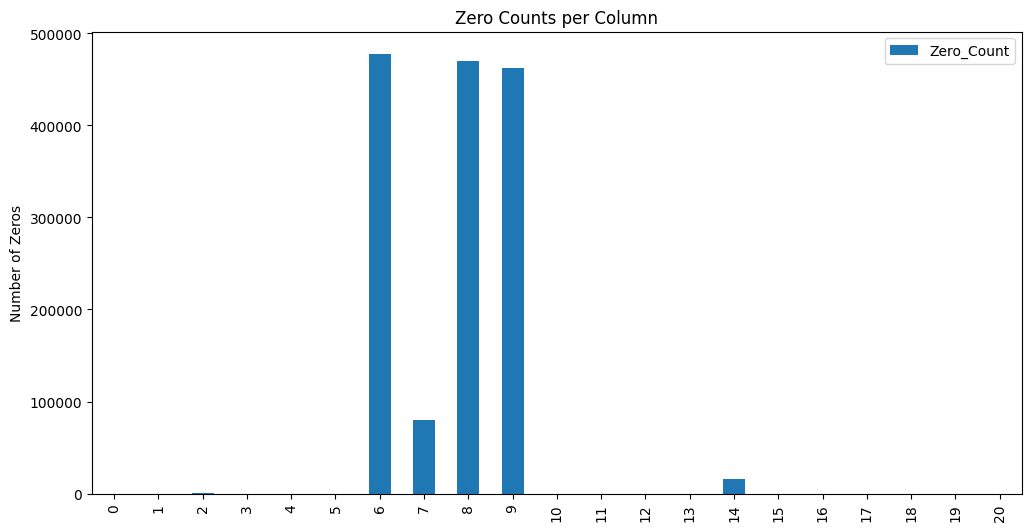

In [ ]:
zero_counts = (main_df == 0).sum().reset_index()
zero_counts.columns = ['Column', 'Zero_Count']
print(zero_counts)

zero_counts.plot(kind='bar', figsize=(12,6))
plt.ylabel('Number of Zeros')
plt.title('Zero Counts per Column')
plt.show()

This means some movies have vote_average = 0 but they have vote_count > 0.

In [ ]:
cols_with_zeros = ['budget', 'revenue', 'runtime']
main_df[cols_with_zeros] = main_df[cols_with_zeros].replace(0, np.nan)

# Fill in zeros with median
main_df['runtime'].fillna(main_df['runtime'].median(), inplace=True)
main_df['budget'].fillna(main_df['budget'].median(), inplace=True)
main_df['revenue'].fillna(main_df['revenue'].median(), inplace=True)

# main_df.dropna(subset=['budget', 'revenue', 'runtime'], inplace=True)

In [ ]:
min_vote_count = 100
print(main_df.shape, kaggle_df.shape)
main_df = main_df[main_df['vote_count'] > min_vote_count]
print(main_df.shape, kaggle_df.shape)

(495557, 21) (1048575, 21)
(173140, 21) (1048575, 21)


In [ ]:
# Define thresholds
runtime_threshold = 300
budget_threshold = main_df['budget'].quantile(0.95)
revenue_threshold = main_df['revenue'].quantile(0.95)

print(budget_threshold)

# Replace out-of-range runtimes
median_runtime = main_df['runtime'].median()
main_df.loc[main_df['runtime'] > runtime_threshold, 'runtime'] = median_runtime

# Replace out-of-range budgets
median_budget = main_df['budget'].median()
main_df.loc[main_df['budget'] > budget_threshold, 'budget'] = median_budget

# Replace out-of-range revenues
median_revenue = main_df['revenue'].median()
main_df.loc[main_df['revenue'] > revenue_threshold, 'revenue'] = median_revenue

275000.0


In [ ]:
# Apply log transformation
main_df['log_revenue'] = np.log1p(main_df['revenue'])

# Now scale the log-revenue between 0 and 1
scaler = MinMaxScaler()
main_df['scaled_log_revenue'] = scaler.fit_transform(main_df[['log_revenue']])

In [ ]:
# Profit
main_df['profit'] = main_df['revenue'] - main_df['budget']

# Release year from release_date
main_df['release_date'] = pd.to_datetime(main_df['release_date'], errors='coerce')
main_df['release_year'] = main_df['release_date'].dt.year

# # Rating category
# main_df['rating_category'] = pd.cut(
#     main_df['vote_average'],
#     bins=[0, 5, 7, 10],
#     labels=['Low', 'Medium', 'High']
# )

In [ ]:
main_df.describe()

,id,vote_average,vote_count,release_date,revenue,runtime,budget,popularity,profit,release_year
count,1.730190e+05,173019.000000,1.730190e+05,168901,1.730190e+05,173019.000000,1.730190e+05,173019.000000,1.730190e+05,168901.000000
mean,3.252356e+05,6.000107,7.097253e+03,1996-09-13 19:39:36.987703040,3.506805e+06,88.690861,3.229014e+05,4.246343,3.183903e+06,1996.206896
min,2.000000e+00,1.000000,1.010000e+02,1900-01-01 00:00:00,1.000000e+00,1.000000,1.000000e+00,0.000000,-3.997857e+06,1900.000000
25%,7.468150e+04,5.300000,1.860000e+02,1984-02-16 00:00:00,3.605496e+06,82.000000,2.750000e+05,1.057000,3.330496e+06,1984.000000
50%,2.215270e+05,6.200000,4.080000e+02,2005-12-05 00:00:00,3.605496e+06,90.000000,2.750000e+05,1.871000,3.330496e+06,2005.000000
75%,4.700755e+05,6.900000,1.356000e+03,2016-01-19 00:00:00,3.605496e+06,103.000000,2.750000e+05,3.871000,3.330496e+06,2016.000000
max,1.410765e+06,9.900000,3.013815e+06,2025-03-07 00:00:00,3.605496e+06,300.000000,4.000000e+06,2994.357000,3.605496e+06,2025.000000
std,3.193864e+05,1.275085,5.061692e+04,NaN,5.403661e+05,33.807111,3.440098e+05,17.749747,6.664456e+05,25.549574


In [ ]:
print(main_df.shape, kaggle_df.shape)

(173019, 23) (1048575, 21)


# **Data Visualizations**

In [ ]:
# Basic info
main_df.info()

# Summary statistics
main_df.describe()

# Check for duplicates
print(f"Number of Duplicates: {main_df.duplicated().sum()}")

# Check missing values
missing_values = main_df.isnull().sum()
print(missing_values[missing_values > 0])

<class 'pandas.core.frame.DataFrame'>
Index: 173019 entries, 0 to 1048512
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    173019 non-null  int64         
 1   title                 173019 non-null  object        
 2   vote_average          173019 non-null  float64       
 3   vote_count            173019 non-null  int64         
 4   status                173019 non-null  object        
 5   release_date          168901 non-null  datetime64[ns]
 6   revenue               173019 non-null  float64       
 7   runtime               173019 non-null  float64       
 8   adult                 173019 non-null  bool          
 9   budget                173019 non-null  float64       
 10  imdb_id               172997 non-null  object        
 11  original_language     173019 non-null  object        
 12  original_title        173019 non-null  object        
 13  ove

Ratings distribution

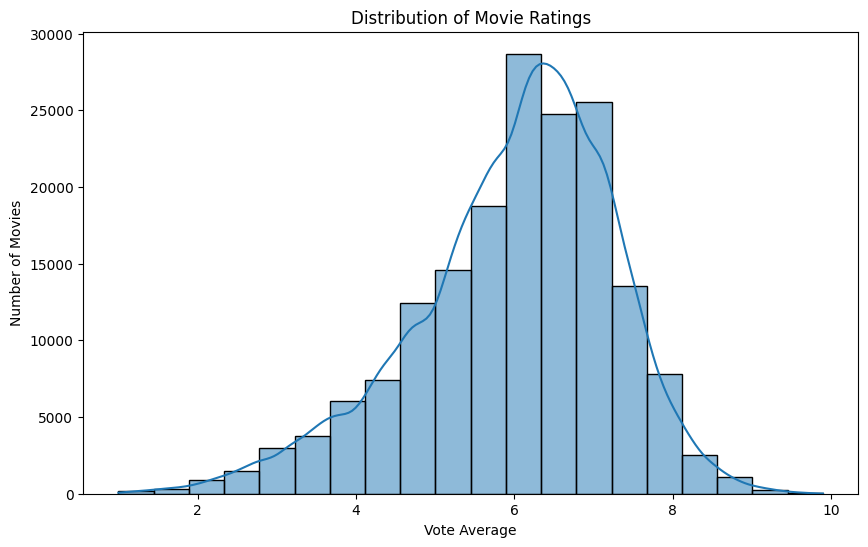

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(main_df['vote_average'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Vote Average')
plt.ylabel('Number of Movies')
plt.show()

Runtime distribution

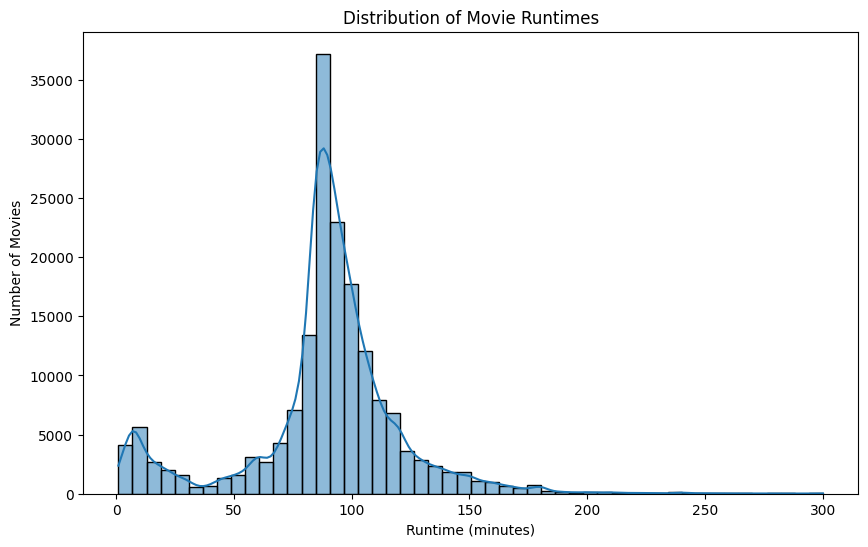

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(main_df['runtime'], bins=50, kde=True)
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.show()


Revenue distribution

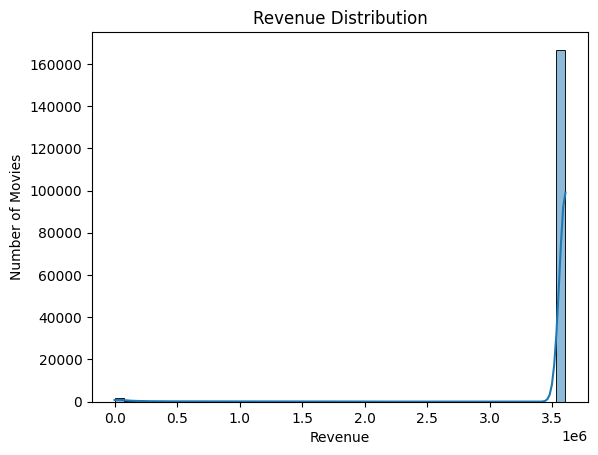

In [ ]:
sns.histplot(main_df['revenue'], bins=50, kde=True)
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Number of Movies')
plt.show()

Budget vs Revenue

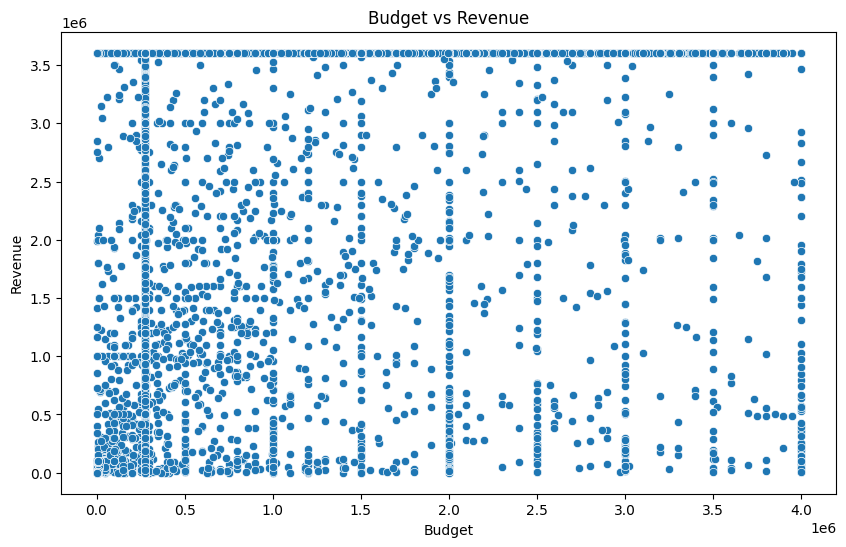

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='budget', y='revenue', data=main_df)
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

Rating vs Popularity

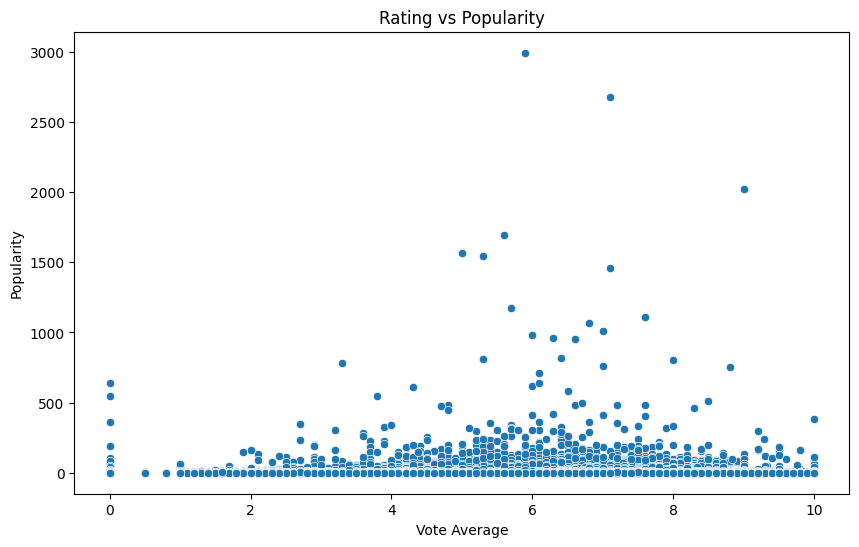

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='vote_average', y='popularity', data=merged_df)
plt.title('Rating vs Popularity')
plt.xlabel('Vote Average')
plt.ylabel('Popularity')
plt.show()

Correlation Heatmap

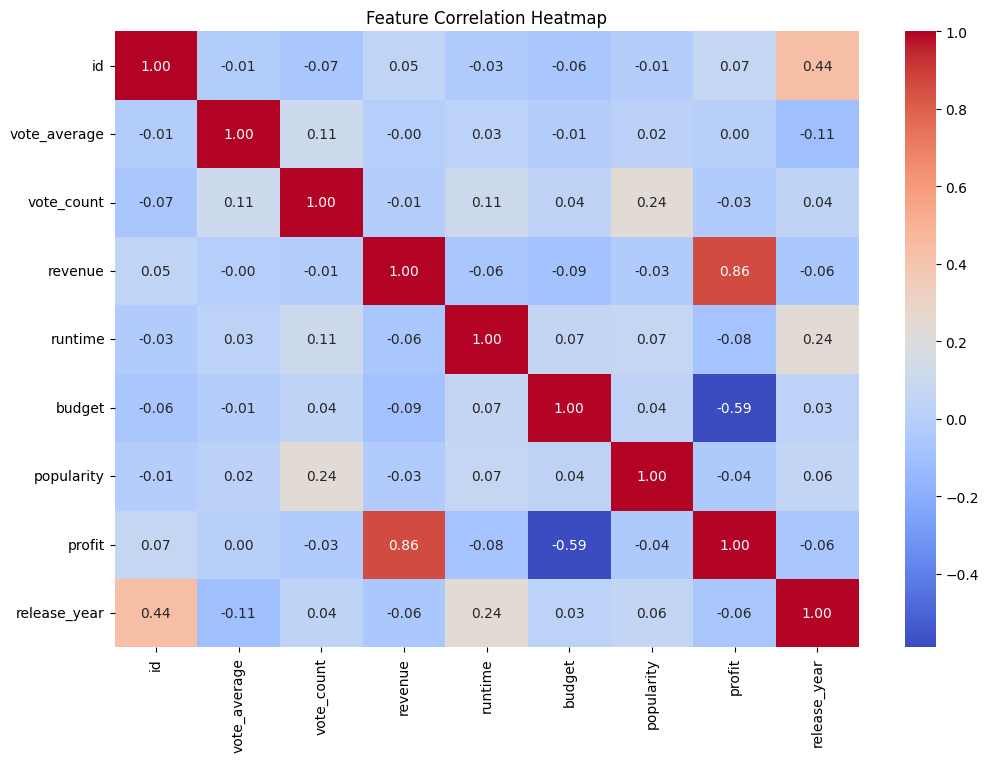

In [ ]:
plt.figure(figsize=(12,8))

# Select only numeric columns
numeric_df = main_df.select_dtypes(include='number')

# Heatmap on numeric columns only
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Feature Correlation Heatmap')
plt.show()

Average Rating Over Years

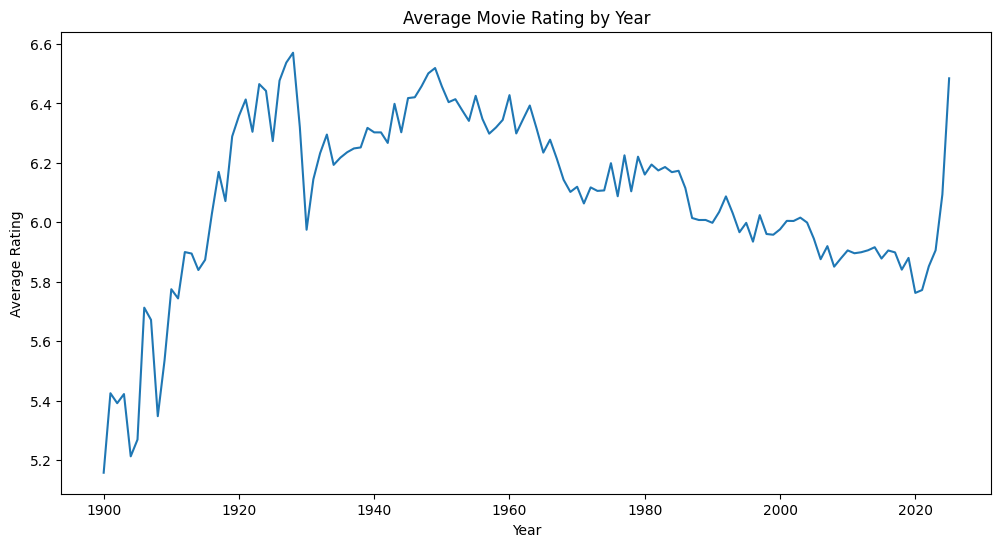

In [ ]:
ratings_by_year = main_df.groupby('release_year')['vote_average'].mean()

plt.figure(figsize=(12,6))
ratings_by_year.plot()
plt.title('Average Movie Rating by Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()

Top Genres

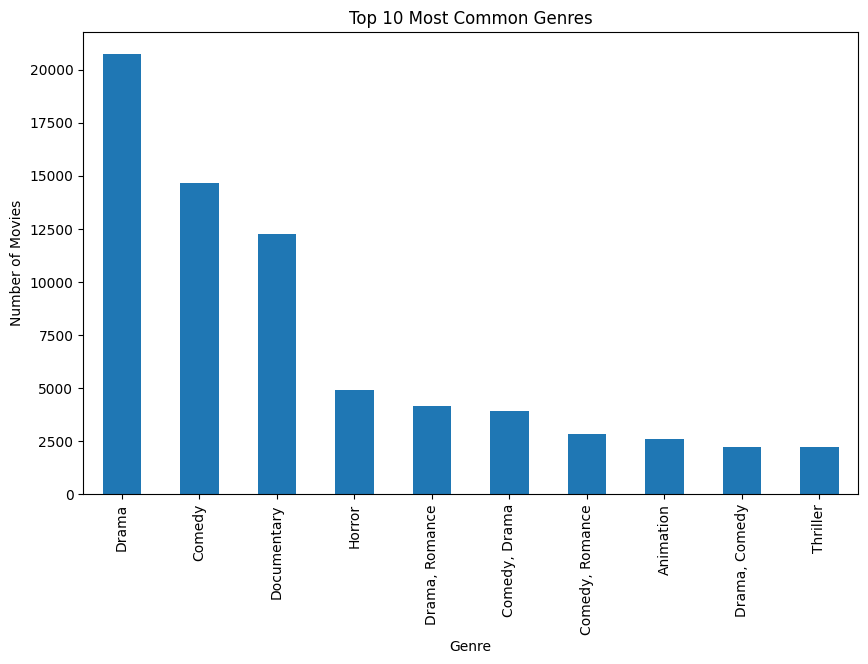

In [ ]:
main_df['genres'].value_counts().head(10).plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Most Common Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.show()

# **Predictive Modeling**

Revenue Prediction using Regression

In [ ]:
# Define features and target
features = ['budget', 'runtime']
X = main_df[features]
y = main_df['scaled_log_revenue']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error: {mse}')

# # Reverse Min-Max scaling
# scaled_preds = model.predict(X_test)
# log_preds = scaler.inverse_transform(scaled_preds.reshape(-1, 1))

# # Reverse log1p
# real_revenue_preds = np.expm1(log_preds)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
print(f"Cross-validated Mean Squared Error: {np.mean(-scores)}")

# Check the standard deviation of revenue
print(main_df['revenue'].std())

# Check if predictions are all similar
predictions = model.predict(X_test)
print(predictions.min(), predictions.max())
###############################
#revenue target is highly skewed and scaled, this is useless

Mean Squared Error: 0.0026959828306174394
Cross-validated Mean Squared Error: 0.002532532337112067
540366.0536089713
0.9689894542683555 0.9995748325905057
